# Problem Set 4: Neural Networks

**Release Date:** 17 Mar 2026

**Due Date:** 11 Apr 2026

## Motivation

Knowing enough to build things from scratch is helpful, but it can be unnecessarily time consuming. 

Deep Learning (DL) models often consist of large numbers of layers which can be unreasonably tedious to manually implement correctly (forward pass behaviors, backpropagation, etc.)

For pragmatic purposes, it is critical to be familiar with **at least one** Machine Learning / Deep Learning (ML/DL) library.

![PyTorch](images/logo.png)

[PyTorch](https://pytorch.org/) is one of the most widely-used DL libraries. It offers a Pythonic API to:
- build \& compose DL layers into models
- preprocess, split, and load data

Its modernity, interface and (as of 2026) popularity make it a great choice for getting started with DL compared to other libraries (e.g., [`JAX`](https://github.com/google/jax), [`TensorFlow`](https://www.tensorflow.org/), etc.)

## Overview

In **Problem Set 4**, you will be guided through four tasks:
1. Build a simple neural network and training it (locally) via backpropagation and stochastic gradient descent. 

2. Build a __Convolutional Neural Network__ (CNN/ConvNet), training it on two datasets, *MNIST* and *CIFAR-10*, and learn __data augmentation__ to enhance your dataset. 

3. Learn the details of RNN, their applications to sequential data, and using a RNN to model and predict patterns in time-series data. 

4. Finally, explore the incorporation of attention layers as a first step toward building a transformer architecture.

This problem set may seem long and daunting at first glance.

However, many cells serve not as **Tasks** but **Demos**, to illustrate important concepts and building blocks you are likely to use in the future.

**Moreover, we provide links every time we invoke a [`PyTorch`](https://pytorch.org/docs/stable/) function (like [`nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)), so if you feel lost, feel free to skim the documentation for more details.**

If you want to explore deep learning concepts more thoroughly, there is also an extra notebook `ps4_supplementary.ipynb` which covers certain concepts in greater detail. It's optional but highly encouraged!

### Outline of the Notebook

The notebook is structured into four main parts, each corresponding to a lecture topic:

* Part 1: NN using PyTorch (Lecture 8)
* Part 2: Convolutional Neural Networks (Lecture 9)
* Part 3: Recurrent Neural Networks (Lecture 10)
* Part 4: Attention Mechanism and Transformers (Lecture 11)

### Required Files
* ps4.ipynb
* data/
    * review_train.csv
    * review_test.csv

### Plagiarism Policy

Please refer to our [Course Policies](https://canvas.nus.edu.sg/courses/85417/pages/course-policies)

<p style="color:red;"><b>Honour Code: Note that plagiarism will not be condoned! You may discuss with your classmates and check the internet for references, but you MUST NOT submit any code/report/explanation that is copied directly from other sources!</b></p>

### Post-Problem Set Survey
Your feedback is important to us! After completing Problem Set 4, please take a moment to share your thoughts by filling out this [survey](https://coursemology.org/courses/3214/surveys/2955).

### Imports

The following lines of code import packages and functions that are necessary
for the following tasks.

As a reminder, please **do not** modify the following lines of code by adding,
removing or modifying the specified imports. 

In [11]:
# RUN THIS CELL FIRST
import math
from collections import OrderedDict

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import v2

import numpy as np
from numpy import allclose, isclose

from collections.abc import Callable

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


# 1 - Neural Networks using PyTorch layers
Before starting, we recommend reading **Extra Chapter 1** in `ps4_supplementary.ipynb` to understand [`PyTorch`](https://pytorch.org/docs/stable/) tensors, and get an idea of how one might implement gradient descent without relying [`PyTorch`](https://pytorch.org/docs/stable/). Then, you'll appreciate the convenience of the powerful [`PyTorch`](https://pytorch.org/docs/stable/) library!

### Demo 1.1 - nn.Module

The [`nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) class is an interface that houses two main methods: 
- `__init__`, where we instantiate our layers and activation functions, and 
- `forward`, that performs the forward pass.

To create our own neural network, we:
1. inherit from the [`nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) parent class 
2. **must** call `super().__init__()` in `__init__` before anything else
3.  implement the `forward` function to specify how a forward pass works in our model.

#### Example 1: Custom Linear Layer
In this example, we will define a custom `LinearLayer` class that inherits `nn.Module`.

We already have one in [`PyTorch`](https://pytorch.org/docs/stable/) (called [`nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)), and that's good! We want familiar modules so we can focus on how the abstraction works. 

Recall a possible way to write a linear layer (in [row-major notation](https://en.wikipedia.org/wiki/Row-_and_column-major_order)) is
$$\mathbf{y} = \mathbf{x}\mathbf{W} + \mathbf{b}$$

where `x` is our input, and `W` and `b` are parameters to be learned.

<div>
<img src="images/toy_nn.png" width="400"/>
</div>

Thus, when coding our `LinearLayer` class, we have to define `self.weight` and `self.bias` as [`nn.Parameter`](https://pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html) objects (this marks them as requiring gradients to be computed during the backward pass).

In [12]:
# Define a linear layer using nn.Module
class LinearLayer(nn.Module):
    """
    Linear layer as a subclass of `nn.Module`.
    """
    def __init__(self, input_dim: int, output_dim: int):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(input_dim, output_dim))
        self.bias = nn.Parameter(torch.randn(output_dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.matmul(x, self.weight) + self.bias

#### Example 2: Composition

The benefits of using [`nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) as an abstraction are manifold:
- **MOST IMPORTANTLY**, [`nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html)s can be infinitely composed 
    - Complex models can be built by combining simpler ones.
- We can organize relevant parameters into a single object
    - This makes it easy to save/load them in a clean way 
    - This lets us shuttle important parameters **as logical groups** between devices (e.g. CPU/GPU).

Here, we made another module `SineActivation` which serves as an activation function.

**(Q: What happens if we don't use any activation function at all?)**

We use it to demonstrate how we can compose our own modules together with [`nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) layers to create a model. (Recall that non-linearities are essential to the expressive power of neural networks!)

In [13]:
class SineActivation(nn.Module):
    """
    Sine activation layer.
    """
    def __init__(self):
        super().__init__()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sin(x)

class Model(nn.Module):
    """
    Neural network created using `LinearLayer` and `SineActivation`.
    """
    def __init__(self, input_size: int, hidden_size: int, output_size: int):
        super(Model, self).__init__()
        self.l1 = LinearLayer(input_size, hidden_size)
        self.act = SineActivation()
        self.l2 = LinearLayer(hidden_size, output_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.l1(x)
        x = self.act(x)
        x = self.l2(x)
        return x
    
input_size = 1
hidden_size = 2
output_size = 1

model = Model(input_size, hidden_size, output_size)

x = torch.tensor([[1.0]])
output = model(x)
print("Original value: ", x)
print("Value after being processed by Model: ", output)

Original value:  tensor([[1.]])
Value after being processed by Model:  tensor([[0.0352]], grad_fn=<AddBackward0>)


### Demo 1.2 - Activation Functions

Just like `SineActivation` in the previous section, PyTorch comes with a variety of built-in activation functions that can be used in your models.

Some activation functions for hidden layers include:

**Sigmoid**([`nn.Sigmoid`](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html))
- Definition: $f(x) = 1 / (1 + e^{-x})$. 

**Tanh (Hyperbolic Tangent)** ([`nn.Tanh`](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html))
- Definition: $f(x) = (e^x - e^{-x}) / (e^x + e^{-x})$. 

**ReLU (Rectified Linear Unit)** ([`nn.ReLU`](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html))
- Definition: $f(x) = \max(0, x)$. 
    - (English) Non-positive inputs are mapped to 0, while positive inputs are left unchanged.
- Significance:
    - ReLU is fast to compute.
    - ReLU partially mitigates the vanishing gradient problem typical of Sigmoid and Tanh
- Uses:
    - Hidden Layers

<div>
<img src="images/sigmoid_tanh_relu.png" width="300"/>
</div>

There are, of course, many more activation functions, which you can read up more on [here](https://docs.pytorch.org/docs/main/nn.html#non-linear-activations-weighted-sum-nonlinearity)

Meanwhile, for output layers, some common activation functions include:

**Sigmoid** ([`nn.Sigmoid`](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html))
- Additionally:
    - Sigmoid maps input values to the range [0, 1].
    - Hence, it is suited for probability estimation (e.g. for binary classification).

**Tanh** ([`nn.Tanh`](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html))
- Additionally:
    - Tanh maps input values to the range [-1, 1].
    - This is good for controlling servos in robotics, hence it is common in those settings.

**Softmax** ([`nn.Softmax`](https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html))
- Definition: $f(x_i) = e^{x_i} / \sum_j e^{x_j}$ for each element $x_i$ in the input vector.
   - (English): A vector of scores is first exponentiated. Then the vector is normalized by the sum of its entries.
- Significance:
    - Softmax generalizes the sigmoid function to multi-class classification problems.
    - Any vector will be transformed into **probability**  vector (no negative entries, sum of entries is 1).

**Linear** ([`nn.Identity`](https://pytorch.org/docs/stable/generated/torch.nn.Identity.html) / no activation)
- Definition: $f(x) = x$.
- Significance:
    - Sometimes, post-processing is not needed (e.g. in regression problems).
    - We can simply use a linear activation (i.e. no activation) in this case.

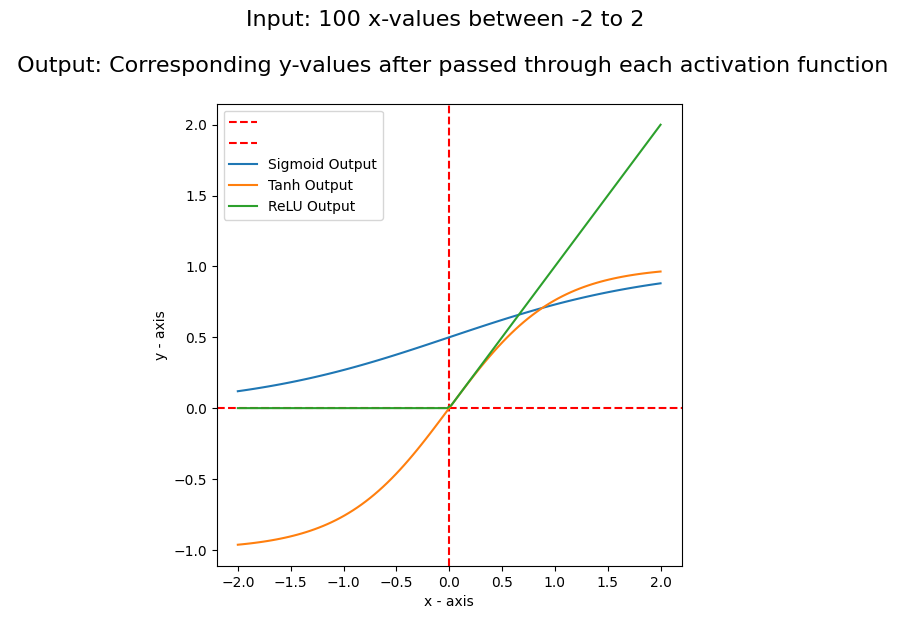

In [14]:
x_sample = torch.linspace(-2, 2, 100)
sigmoid_output = nn.Sigmoid()(x_sample).detach().numpy()
tanh_output = nn.Tanh()(x_sample).detach().numpy()
relu_output = nn.ReLU()(x_sample).detach().numpy()

f = plt.figure()
f.set_figwidth(6)
f.set_figheight(6)
plt.xlabel('x - axis')
plt.ylabel('y - axis')
plt.title("Input: 100 x-values between -2 to 2 \n\n Output: Corresponding y-values after passed through each activation function\n", fontsize=16)
plt.axvline(x=0, color='r', linestyle='dashed')
plt.axhline(y=0, color='r', linestyle='dashed')
plt.plot(x_sample, sigmoid_output)
plt.plot(x_sample, tanh_output)
plt.plot(x_sample, relu_output)
plt.legend(["","","Sigmoid Output", "Tanh Output", "ReLU Output"])
plt.show()

### Demo 1.3 - PyTorch Optimisers

Beyond just Pythonic design, `PyTorch` also automatically handles differentiation and gradient computations for us.
- Fun fact: this is [a bona fide computational paradigm](https://arxiv.org/pdf/2403.14606) for the programming language buffs out there!

Whenever we use `nn.Parameter`s in our computations, `PyTorch` lazily records their derivative, which we can compute via the `backward()` method.
- For example, we can do `loss.backward()` to compute the derivative of the loss with respect to all parameters (with `requires_grad=True`) involved in the computation of the loss, and it will be stored automatically (in the' **.grad** attribute).

But nothing is done with the gradients until we use an [`optimizer`](https://pytorch.org/docs/stable/optim.html) which tells us how to update the parameters based on the gradients.
- This is a very useful abstraction!
    - While you may have only come across [Stochastic Gradient Descent](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) in this course, there are many more ways to update parameters with gradients (e.g. [Adam](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html), [RMSProp](https://pytorch.org/docs/stable/generated/torch.optim.RMSprop.html), etc.).

Let's see how we use an [optimizer](https://pytorch.org/docs/stable/optim.html) to update parameters below:

In [15]:
# Suppose we had an nn.Parameter x (or really, any tensor with requires_grad=True)
x = torch.tensor([1.0], requires_grad=True)

# We would like to update it with SGD, so we create an optimiser for it.
optimiser = torch.optim.SGD([x], lr=0.1)

# Hence, we compute some random function (usually, this is your loss function) in x...
y = x ** 2 + 2 * x

# And start the backpropagation process:
# Compute the gradients of y with respect to x, and store it in x.grad
y.backward()

print("Value of x before it is updated by optimiser: ", x)
print("Gradient stored in x after backpropagation: ", x.grad)

# Make the optimizer update x based on x.grad.
optimiser.step()

# You should expect to see x = x - lr * x.grad = 1.0 - 0.1 * 4.0 = 0.60
print("Value of x after it is updated by optimiser: ", x)

# Now that gradients are no longer needed, we discard them by setting them to zero.
optimiser.zero_grad()
print("Gradient stored in x after zero_grad is called: ", x.grad)

Value of x before it is updated by optimiser:  tensor([1.], requires_grad=True)
Gradient stored in x after backpropagation:  tensor([4.])
Value of x after it is updated by optimiser:  tensor([0.6000], requires_grad=True)
Gradient stored in x after zero_grad is called:  None


/home/sad/Documents/GitHub/nus/CS2109_Introduction_to_AI_and_Machine_Learning/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:841: UserWarning: XPU device count is zero! (Triggered internally at /pytorch/c10/xpu/XPUFunctions.cpp:115.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


If you need more help visualizing how backpropagation and the gradient descent loop could look like in code, you can refer to [Demo 1.7 of the extra notebook](ps5_supplementary.ipynb#Demo-1.7---Backpropagation-and-Gradient-Descent-in-Code) for a scaffolded exercise.

In [16]:
# Run to view your model weights
print(model.state_dict())

OrderedDict({'l1.weight': tensor([[ 0.3709, -0.7218]]), 'l1.bias': tensor([-2.1308,  0.0998]), 'l2.weight': tensor([[ 0.3380],
        [-0.2411]]), 'l2.bias': tensor([0.2267])})


Additionally, you may want to visualize your training process by plotting the loss curve, or perhaps inspect mid-training tensor values for analysis.

However, by default, model outputs or intermediate tensor values have `requires_grad=True` and are part of the computational graph, so they cannot be directly converted to NumPy arrays, as NumPy lacks support for gradients, GPU tensors, or computational graphs. Visualization libraries like [`matplotlib`](https://matplotlib.org/) require NumPy arrays, so we need to convert our tensors appropriately.

To convert a tensor to a NumPy array, we first need to detach it from the computational graph and move it to the CPU (if you are using a GPU). We can do this using the [`Tensor.detach()`](https://pytorch.org/docs/stable/generated/torch.Tensor.detach.html#torch.Tensor.detach) method followed by [`Tensor.cpu()`](https://pytorch.org/docs/stable/generated/torch.Tensor.cpu.html#torch.Tensor.cpu) if necessary, and then call [`Tensor.numpy()`](https://pytorch.org/docs/stable/generated/torch.Tensor.numpy.html#torch.Tensor.numpy) to get the NumPy array.

In [17]:
x = torch.tensor([[1.0]], requires_grad=True)

# This will throw an error as x is still part of the computational graph, and cannot be converted to a NumPy array.
try:
    x_numpy = x.numpy()
except Exception as e:
    print("Error: ", e)

# You should expect to successfuly convert x to a NumPy array after detaching 
# it from the computational graph and moving it to the CPU (if necessary).
x_numpy = x.detach().numpy() # You may need to additionally call .cpu() if you are using a GPU, i.e. x.detach().cpu().numpy()
print("Successfully converted x to a NumPy array: ", x_numpy)

Error:  Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.
Successfully converted x to a NumPy array:  [[1.]]


### TASK - Using NN to recognize handwritten digits

Now we will be building a neural network to classify images from the **MNIST Handwritten Digits** dataset, a rite of passage for anyone interested in Deep Learning.

Each image is a $28 \times 28$ grayscale image (tensor) that looks something like:

<img src="https://upload.wikimedia.org/wikipedia/commons/2/27/MnistExamples.png" width="500" />

MNIST is a classification problem and the task is to take in an input image and classify them into one of ten buckets: the digits from $0$ to $9$. 

### Demo 1.4 - Loading an external dataset

`PyTorch`, being ever so convenient, has built-in support for loading popular/classic datasets like MNIST.

MNIST, in particular, is pre-split into train and test sets, and we'll load it for you below:

The download takes approximately 63MB of space.

In [18]:
# DO NOT REMOVE THIS CELL – THIS DOWNLOADS THE MNIST DATASET
# RUN THIS CELL BEFORE YOU RUN THE REST OF THE CELLS BELOW

# This downloads the MNIST datasets ~63MB
mnist_train = datasets.MNIST("./", train=True, download=True)
mnist_test  = datasets.MNIST("./", train=False, download=True)

x_train = mnist_train.data.reshape(-1, 784) / 255
y_train = mnist_train.targets
    
x_test = mnist_test.data.reshape(-1, 784) / 255
y_test = mnist_test.targets

### Task 1.1 - Define the model architecture and implement the forward pass

Here's a diagram of the model you will be implementing:

<div>
<img src="images/img_linear_nn.png", width=700>
</div>

In our data, a given image $x$ has been flattened from a $28 \times 28$ image to a 784-length array.

Your task is to create a 3-layer network `DigitNet`.
`DigitNet` inherits from `nn.Module` and should implement the following methods:
- `__init__`: initializes all the layers and activation functions of our model.
- `forward`: takes in **an image** and outputs the **pre-softmax scores** for each class
    - (Why pre-softmax?) [`nn.CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) will perform a softmax for us during the loss computation, so we don't need to do it in the forward pass.
    - Your `forward pass` should look like this (remember, no softmax yet!):
$$x \rightarrow \text{Linear(512)} \rightarrow \text{ReLU} \rightarrow \text{Linear(128)} \rightarrow \text{ReLU} \rightarrow \text{Linear(10)}$$

__Reminder:__ Do not hardcode for the number of classes. Use the `num_classes` constructor argument instead.

In [19]:
class DigitNet(nn.Module):
    def __init__(self, input_dimensions: int, num_classes: int): # set the arguments you'd need
        super().__init__()
        """
        YOUR CODE HERE
        - DO NOT hardcode the input_dimensions, use the parameter in the function
        - Your network should work for any input and output size 
        - Create the 3 layers (and a ReLU layer) using the torch.nn layers API
        """
        """ YOUR CODE HERE """
        self.l1 = nn.Linear(input_dimensions, 512)
        self.l2 = nn.ReLU()
        self.l3 = nn.Linear(512, 128)
        self.l4 = nn.ReLU()
        self.l5 = nn.Linear(128, num_classes)
        """ YOUR CODE END HERE """
        
    def predict_proba(self, x: torch.Tensor) -> torch.Tensor:
        """
        
        Same as the forward pass, except this outputs probabilities 
        for each class for each input, instead of the predicted class.

        Parameters
        ----------
        x : Input tensor (batch size is the entire dataset)

        Returns
        -------
            The output probabilities for each class for each input.
        """
        
        out = self.forward(x)
        return torch.softmax(out, dim=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Performs the forward pass for the network.
        
        Parameters
        ----------
        x : Input tensor (batch size is the entire dataset)

        Returns
        -------
            The output of the entire 3-layer model.
        """
        
        """
        YOUR CODE
        
        - Pass the inputs through the sequence of layers
        - Run the final output through the Softmax function on the right dimension!
        """
        """ YOUR CODE HERE """
        x = self.l1(x)
        x = self.l2(x)
        x = self.l3(x)
        x = self.l4(x)
        return self.l5(x)
        """ YOUR CODE END HERE """


In [20]:
# Test cases
model = DigitNet(784, 10)
print([layer.detach().numpy().shape for name, layer in model.named_parameters()] )
assert [layer.detach().numpy().shape for name, layer in model.named_parameters()] \
        == [(512, 784), (512,), (128, 512), (128,), (10, 128), (10,)]

[(512, 784), (512,), (128, 512), (128,), (10, 128), (10,)]


### Demo 1.5 - DataLoaders

Now we would like to train our model on the MNIST dataset. 

Most generally, we can imagine this as sampling a subset of the data, and then performing the training loop.

Think about it:
- Stochastic Gradient Descent (SGD) is roughly the method we are describing when we draw a subset of size 1.
- Mini-batch Gradient Descent is the corresponding method when we draw a subset of size greater than 1.
- Gradient Descent is the corresponding method when our subset is the entire dataset (it isn't very random, is it...)

Of course, **PyTorch** has a built-in abstraction to cover all these bases: the [`DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

PyTorch [`DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) helps us to randomly/sequentially draw mini-batches of data from a dataset.

If enabled, it also shuffles the data at the start of each epoch, allowing the model to see differently-batched data every epoch.

**Note for the curious**: Textbook Machine Learning theory actually requires that we draw samples independently and identically distributed (i.i.d.) from the dataset. We don't exactly do this, but random shuffling reduces variance without introducing bias, so it is a common practice in training neural networks.

In [21]:
# Run this code before moving on.
# DO NOT EDIT!
train_set = TensorDataset(x_train, y_train)
test_set = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_set, shuffle=True, batch_size = len(train_set))
# We don't shuffle the test set; we don't learn from it anyway, that effort is wasted.
test_loader = DataLoader(test_set, shuffle=False, batch_size = len(test_set))

### Task 1.2 - Training Loop

Now you have all the tools required to write a basic model loop!

Your task is to implement `train_model`, a glorified for-loop to perform the following for every iteration (epoch/minibatch):

1. set the optimizer's gradients to zero
2. perform a forward pass
3. calculate the loss
4. backpropagate using the loss
5. take an optimzer step to update weights

Notes:
1. Use the [`torch.optim.Adam`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#torch.optim.Adam) optimiser to train the network.
2. Since we are performing multi-class classification, we use Cross-Entropy Loss ([`nn.CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html#torch.nn.CrossEntropyLoss)).
3. `train_model` should train for **20 epochs**.

*Note: refer to the command glossary to find out how to instantiate optimisers, losses, and more*

In [22]:
def train_model(model: nn.Module, dataloader: DataLoader, epochs: int = 20):
    """
    Trains the model for a specified number of epochs/iterations
    
    Parameters
    ---------- 
        model: A PyTorch model to be trained
        dataloader : A DataLoader object that provides batches of the training data
        epochs  : Number of epochs, default of 20
        
    Returns
    -------
        The final model and the loss curve (per epoch)
    """

    losses = []
    loss_fn = nn.CrossEntropyLoss()
    # Set model to training mode. 
    # See (https://stackoverflow.com/questions/60018578/what-does-model-eval-do-in-pytorch) if curious.
    model.train() 
    optimiser = torch.optim.Adam(model.parameters())
    for i in range(epochs):
        for x_batch, y_batch in dataloader:
            epoch_loss = 0.0
            y_output = model.predict_proba(x_batch)
            loss = loss_fn(y_output, y_batch)
            epoch_loss += loss.item()
            loss.backward()
            optimiser.step()
        optimiser.zero_grad()
        print(f"Epoch {i+1}/{epochs}, Loss: {epoch_loss:.4f}")
        losses.append(epoch_loss)

    return model, losses

digit_model, losses = train_model(DigitNet(784, 10), train_loader)
print(digit_model)

Epoch 1/20, Loss: 2.3025
Epoch 2/20, Loss: 2.2959
Epoch 3/20, Loss: 2.2881
Epoch 4/20, Loss: 2.2768
Epoch 5/20, Loss: 2.2612
Epoch 6/20, Loss: 2.2402
Epoch 7/20, Loss: 2.2136
Epoch 8/20, Loss: 2.1827
Epoch 9/20, Loss: 2.1484
Epoch 10/20, Loss: 2.1097
Epoch 11/20, Loss: 2.0667
Epoch 12/20, Loss: 2.0235
Epoch 13/20, Loss: 1.9831
Epoch 14/20, Loss: 1.9439
Epoch 15/20, Loss: 1.9052
Epoch 16/20, Loss: 1.8696
Epoch 17/20, Loss: 1.8387
Epoch 18/20, Loss: 1.8098
Epoch 19/20, Loss: 1.7802
Epoch 20/20, Loss: 1.7540
DigitNet(
  (l1): Linear(in_features=784, out_features=512, bias=True)
  (l2): ReLU()
  (l3): Linear(in_features=512, out_features=128, bias=True)
  (l4): ReLU()
  (l5): Linear(in_features=128, out_features=10, bias=True)
)


In [214]:
# Test cases
x_train_new = torch.rand(5, 784, requires_grad=True)
y_train_new = torch.ones(5, dtype=torch.uint8)

train_set_new = TensorDataset(x_train_new, y_train_new)

train_loader_new = DataLoader(train_set_new, shuffle=True, batch_size = len(train_set_new))


assert isinstance(train_model(DigitNet(784, 10), train_loader_new)[0], DigitNet)

Epoch 1/20, Loss: 2.3007
Epoch 2/20, Loss: 2.1905
Epoch 3/20, Loss: 1.9613
Epoch 4/20, Loss: 1.6638
Epoch 5/20, Loss: 1.4992
Epoch 6/20, Loss: 1.4657
Epoch 7/20, Loss: 1.4616
Epoch 8/20, Loss: 1.4612
Epoch 9/20, Loss: 1.4612
Epoch 10/20, Loss: 1.4612
Epoch 11/20, Loss: 1.4612
Epoch 12/20, Loss: 1.4612
Epoch 13/20, Loss: 1.4612
Epoch 14/20, Loss: 1.4612
Epoch 15/20, Loss: 1.4612
Epoch 16/20, Loss: 1.4612
Epoch 17/20, Loss: 1.4612
Epoch 18/20, Loss: 1.4612
Epoch 19/20, Loss: 1.4612
Epoch 20/20, Loss: 1.4612


Extra tip: You should expect the loss to be **SOMEWHERE** around $ln(n)$ for a model where $n$ is the number of classes (10 for MNIST). (Think about the Cross-Entropy Loss formula for why)

There are a number of assumptions for this, including a good parameter initialization scheme, etc.

(did you know `PyTorch`'s default behavior isn't just fill your weights with random garbage, rather it draws from specific distributions instead?)

However, it is a good rule of thumb to know whether you set everything up well:
- If your starting loss is much higher than $-ln(n)$...
    - your output layer probably has the wrong shape
    - or you made some arithmetic mistake in wiring your layers together.
- If your starting loss is much lower than $-ln(n)$...
    - you either have a flawed set of initial values
    - or you accidentally applied some other nonlinearity before the final softmax (like ReLU)

Not an exhaustive list, but the point is you should be suspicious.

### Demo 1.6 - Explore your model

Now that we have trained the model, let us run some predictions on the model.

true label: 6
pred label: 6


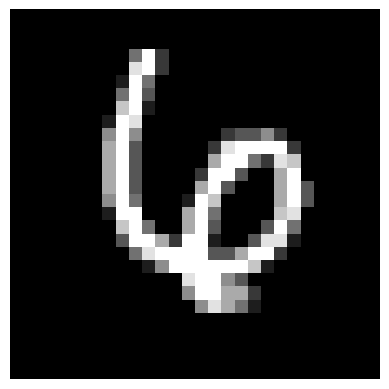

In [215]:
# This is a demonstration: You can use this cell for exploring your trained model

idx = 22 # try on some index

scores = digit_model(x_test[idx:idx+1])
_, predictions = torch.max(scores, 1)
print("true label:", y_test[idx].item())
print("pred label:", predictions[0].item())

plt.imshow(x_test[idx].numpy().reshape(28, 28), cmap='gray')
plt.axis("off")
plt.show()

### Task 1.3 - Evaluate the Model

Now that we have trained the model, we should evaluate it with the test set. (why?)

We will be using **accuracy** (% of the time model predicted the correct digit) as our evaluation metric.

In [34]:
def get_accuracy(scores: torch.Tensor, labels: torch.Tensor) -> int | float:
    """
    Helper function that returns accuracy of model
    
    Parameters
    ----------
        scores : The raw softmax scores of the network
        labels : The ground truth labels
        
    Returns
    -------
        Accuracy of the model. Return a number in range [0, 1].
        0 means 0% accuracy while 1 means 100% accuracy
    """
    """ YOUR CODE HERE """
    _, predictions = torch.max(scores, 1)
    return sum(predictions == labels)/len(labels)
    """ YOUR CODE END HERE """
scores = digit_model.predict_proba(x_test) # n x 10 tensor
get_accuracy(scores, y_test)

tensor(0.8319)

In [217]:
# Test cases
scores = torch.tensor([[0.4118, 0.6938, 0.9693, 0.6178, 0.3304, 0.5479, 0.4440, 0.7041, 0.5573,
         0.6959],
        [0.9849, 0.2924, 0.4823, 0.6150, 0.4967, 0.4521, 0.0575, 0.0687, 0.0501,
         0.0108],
        [0.0343, 0.1212, 0.0490, 0.0310, 0.7192, 0.8067, 0.8379, 0.7694, 0.6694,
         0.7203],
        [0.2235, 0.9502, 0.4655, 0.9314, 0.6533, 0.8914, 0.8988, 0.3955, 0.3546,
         0.5752],
        [0,0,0,0,0,0,0,0,0,1]])
y_true = torch.tensor([5, 3, 6, 4, 9])
acc_true = 0.4
assert isclose(get_accuracy(scores, y_true),acc_true) , "Mismatch detected"
print("passed")

passed


### Demo 1.7 - Save and load models

What good is a model that can't be deployed?

Therefore, any [`nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) can be saved and loaded for later use.

We'll show you how to save / load models in the cell below:

In [218]:
# Save your MNIST model for later use!
torch.save(digit_model.state_dict(), "task1")

# Load from the saved model state dict
new_digit_model = DigitNet(784, 10)
new_digit_model.load_state_dict(torch.load("task1"))

<All keys matched successfully>

The above is the recommended way to save models, as it is more flexible and less error-prone.

([**NOT RECOMMENDED**](https://discuss.pytorch.org/t/comparison-between-saving-the-whole-model-saving-only-state-dict-and-torchscript/196033))
Alternatively, you can save/load the entire model too:
```
torch.save(model, "path/to/model")

model = torch.load("path/to/model")
```

# 2 - Convolutional Neural Networks (CNN)

One of the fun things about Deep Learning is that you can solve the same problem with many different architectures!

Let's work on MNIST again but **with CNNs** this time.

Instead of being a $784$-length vector, we now present our images as $1 \times 28 \times 28$ tensors:
- Height $28$-px;
- Width $28$-px;
- and $1$ colour channel (grayscale, in this case).

CNNs are ideal for image-related tasks because they employ convolutional operations, enabling powerful and efficient feature extraction.

But don't take our word for it; try it out yourself!

Read **Extra Chapter 2** in `ps4_supplementary.ipynb` for an explanation and implementation details of **convolution** and **pooling**, two fundamental concepts behind the magic of CNNs!

In [2]:
# do not remove this cell
# run this before moving on

T = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

"""
Note: If you updated the path to the directory containing `MNIST` 
directory, please update it here as well.
"""
mnist_train = datasets.MNIST("./", train=True, download=False, transform=T)
mnist_test = datasets.MNIST("./", train=False, download=False, transform=T)

"""
if you feel your computer can't handle too much data, you can reduce the batch
size to 64 or 32 accordingly, but it will make training slower. 

We recommend sticking to 128 but do choose an appropriate batch size that your
computer can manage. The training phase tends to require quite a bit of memory.
"""
train_loader = DataLoader(mnist_train, shuffle=True, batch_size=256)
test_loader = DataLoader(mnist_test, batch_size=10000)

Feature batch shape: torch.Size([256, 1, 28, 28])
Labels batch shape: torch.Size([256])


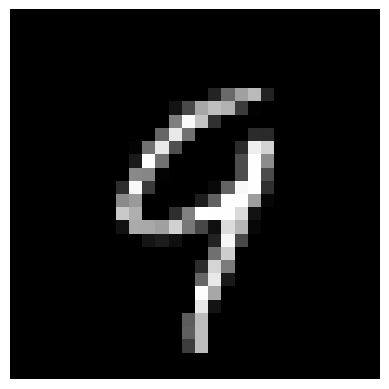

Label: 9


In [3]:
# No need to edit this. Just run the cell and move on

train_features, train_labels = next(iter(train_loader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()
print(f"Label: {label}")

### Demo 2.1 - Building a ConvNet

A basic CNN is typically composed of two parts:
1. A **series of convolutional and pooling layers** (AKA the "feature extractor") to extract features from the input data:
    - Recall that convolutional layers (such as [`nn.Conv1d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html), [`nn.Conv2d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), etc.) extract local features from the input data via kernels.
    - Recall that pooling layers (such as [`nn.MaxPool2d`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)) downsample the feature maps to reduce spatial dimensions and capture more abstract features.
2. A **series of [`nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) layers** (AKA the "dense/fully-connected layers") to perform tasks based on the extracted features.

This demo shows you how such a simple CNN is constructed in [`PyTorch`](https://pytorch.org/docs/stable/).

In [221]:
# Demo
class RawCNN(nn.Module):
    """
    CNN model using Conv2d and MaxPool2d layers.
    """
    def __init__(self, classes: int):
        super().__init__()
        """
        classes: integer that corresponds to the number of classes for MNIST
        """
        # Convolution Layer for 1 input channel, 32 filters, and a 3x3 kernel size
        self.conv1 = nn.Conv2d(1, 32, (3,3))
        # MaxPool layer with kernel size 2x2
        self.mp1 = nn.MaxPool2d((2,2))

        # [LeakyReLU](https://pytorch.org/docs/stable/generated/torch.nn.LeakyReLU.html) with negative slope of 0.1
        # This is a common modification of ReLU to prevent the "dying ReLU" phenomenon, where neurons can get stuck and only output zero.
        self.lrelu = nn.LeakyReLU(0.1)

        # Try guessing what this does!
        self.conv2 = nn.Conv2d(32, 64, (3,3))
        self.mp2 = nn.MaxPool2d((2,2))

        self.l1 = nn.Linear(64*5*5, 256)
        self.l2 = nn.Linear(256, 128)
        self.l3 = nn.Linear(128, classes)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Warning: You need to add nonlinearities between each convolution layer,
        #          otherwise your combined layers will act identically to a single convolution layer!
        x = self.conv1(x)
        x = self.mp1(x)
        x = self.lrelu(x)

        x = self.conv2(x)
        x = self.mp2(x)
        x = self.lrelu(x)   
        
        x = x.view(-1, 64*5*5) # Flattening for our linear layers -- DO NOT REMOVE THIS LINE

        x = self.l1(x)
        x = self.lrelu(x)
        x = self.l2(x)
        x = self.lrelu(x)
        out = self.l3(x)
        
        return out
    
    def predict_proba(self, x: torch.Tensor) -> torch.Tensor:
        out = self.forward(x)
        return torch.softmax(out, dim = 1)
    
    def predict(self, x: torch.Tensor) -> torch.Tensor:
        out = self.predict_proba(x)
        _, predicted = torch.max(out, dim = 1)
        return predicted

# Test the network's forward pass
num_samples, num_channels, width, height = 20, 1, 28, 28
x = torch.rand(num_samples, num_channels, width, height)
net = RawCNN(10)
y = net(x)
print(y.shape) # torch.Size([20, 10])

torch.Size([20, 10])


**Note for the curious**: we actually seldom use max and mean pooling layers in **modern** deep learning. ([Matoba, Dimitriadis, Fleuret, 2023](https://fleuret.org/papers/matoba-et-al-tmlr2023.pdf))

The principal way to understand this is that pooling layers of kernel size $d_1 \times d_2$ are technically learnable with at most **logarithmic** layers of convolution + ReLU (e.g. because `max(a, b) = (a + b + ReLU(a - b) + ReLU(b - a))/2`, and the case for $d_1 \times d_2$ can be extended via recursion).

This is corroborated in ([Springenberg et al., 2015](https://arxiv.org/pdf/1412.6806)), where using **strided convolutions** allows us to achieve the same effect as pooling layers, while still allowing the model to learn the downsampling operation.

However, pooling layers remain simple, effective, and possibly even more robust ([Matoba, Dimitriadis, Fleuret, 2023](https://fleuret.org/papers/matoba-et-al-tmlr2023.pdf)), so they still have their place in the deep learning toolbox.

### Concept: Dropout

__Dropout__ ([*Srivastava et al., 2014*](https://www.jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf)) is a regularisation technique that randomly sets the output of neurons to zero during training with a specified probability `p` (the "dropout rate").

A visualisation of one realisation when using dropout:

<img src="images/dropout.png" width=600>

### How Dropout helps
This is the main gist you will want to remember for this course:
-  Dropout randomly disables neurons during training, which has a powerful regularization effect. 
- By forcing the network to achieve good results with different subsets of active neurons at every step, it essentially trains an ensemble of many different, sparser networks simultaneously. 
- This prevents overfitting because no single neuron can become overly specialized, ensuring a more robust and generalized model.

#### Dropout in PyTorch
To use Dropout in a network, we can create an [`nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html) layer in our `__init__` method of the model class:

```python
class Model(nn.Module):
    def __init__(self, ..., drop_prob):
        super().__init__()
        self.l1 = ...
        ...
        self.dropout = nn.Dropout(p=drop_prob)
        ...
        self.ln = ...

    def forward(self, x):
        x = self.l1(x)
        ...
        x = self.dropout(x)
        ...
        out = ...
        
        return out
```

__Note for the curious:__ Other than [`nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html), there is [`nn.Dropout2d`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout2d.html) in PyTorch. Instead of randomly zero-ing out neurons, `Dropout2d` randomly zero-es out the entire channels of the input. 

[`nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html) is best used with non-spatial data or data that has been flattened, which is typical for fully connected layers. [`nn.Dropout2d`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout2d.html) is designed for spatial data, making it ideal for use right after convolutional and pooling layers in CNNs.

For the sake of this problem set, You should choose one of them to be but __NOT both__ in your neural network.

---

### Task 2.1 - Building a ConvNet with Dropout

Let's use Dropout with CNNs to train a more powerful model on MNIST! 

Implement a CNN `ConvDigitNet` with the following architecture:
$$
\text{Conv(32, (3,3))} \rightarrow \text{MP(2,2)} \rightarrow \text{LReLU(0.1)} \rightarrow \textbf{DO(prob)} \rightarrow \\
\text{Conv(64, (3,3))} \rightarrow \text{MP(2,2)} \rightarrow \text{LReLU(0.1)} \rightarrow \textbf{DO(prob)} \rightarrow \\
\text{Flat} \rightarrow \text{L(1600, 256)} \rightarrow \text{LReLU(0.1)} \rightarrow \textbf{DO(prob)} \rightarrow \\
\text{L(256, 128)} \rightarrow \text{LReLU(0.1)} \rightarrow \text{L(128, 10)} \rightarrow \text{Softmax}
$$

where 
- [`Conv`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) is a Convolution layer with the specified output channels and kernel size, with no padding and a stride of 1 by default.

- [`MP`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) is the Max Pooling layer with the specified kernel size, with no padding, the stride set to the same shape as the kernel by default.

- [`LReLU`](https://pytorch.org/docs/stable/generated/torch.nn.LeakyReLU.html) is Leaky ReLU with the specified negative slope.

- `Flat` is the flattening operation which has already been implemented for you.

- [`L`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) is a fully-connected layer with the specified input and output features.
 
- [`DO`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html) is Dropout with a dropping probability. Choose between `nn.Dropout` and `nn.Dropout2d` but __not both__ for your network.

__Reminders:__ 
- Do not hardcode for the number of classes and the dropout probability. Use the `classes` and `drop_prob` constructor arguments instead.
- (**DO NOT USE SOFTMAX IN YOUR FORWARD PASS**) [`nn.CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) already performs a softmax for us during the loss computation, so we don't need to do it in the forward pass.
- **Instantiate all layers in `__init__`** before you use them in `forward`.

In [222]:
class DropoutCNN(nn.Module):
    """
    CNN that uses Conv2d, MaxPool2d, and Dropout layers.
    """
    def __init__(self, classes: int, drop_prob: float = 0.5):
        super().__init__()
        """
        classes: integer that corresponds to the number of classes for MNIST
        drop_prob: probability of dropping a node in the neural network
        """
        """ YOUR CODE HERE """
        self.conv1 = nn.Conv2d(1, 32, (3,3))
        self.mp1 = nn.MaxPool2d((2,2))
        self.lrelu1 = nn.LeakyReLU(0.1)
        self.do1 = nn.Dropout(drop_prob)

        self.conv2 = nn.Conv2d(32, 64, (3,3))
        self.mp2 = nn.MaxPool2d((2,2))
        
        self.l1 = nn.Linear(1600, 256)
        self.l2 = nn.Linear(256, 128)
        self.l3 = nn.Linear(128, classes)
        """ YOUR CODE END HERE """
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """ YOUR CODE HERE """
        x = self.conv1(x)
        x = self.mp1(x)
        x = self.lrelu1(x)
        x = self.do1(x)
        x = self.conv2(x)
        x = self.mp2(x)
        x = self.lrelu1(x)
        x = self.do1(x)
        """ YOUR CODE END HERE """
        
        x = x.view(-1, 64*5*5) # Flattening – do not remove

        """ YOUR CODE HERE """
        x = self.l1(x)
        x = self.lrelu1(x)
        x = self.do1(x)
        x = self.l2(x)
        x = self.lrelu1(x)
        x = self.l3(x)
        return x
        """ YOUR CODE END HERE """
    
    def predict_proba(self, x: torch.Tensor) -> torch.Tensor:
        out = self.forward(x)
        return torch.softmax(out, dim = 1)



# Test cases
# Test your network's forward pass
num_samples, num_channels, width, height = 20, 1, 28, 28
x = torch.rand(num_samples, num_channels, width, height)
net = DropoutCNN(10)
y = net(x)
print(y.shape) # torch.Size([20, 10])

torch.Size([20, 10])


### Demo 2.2 - Training your Vanilla and Dropout CNNs

Now we want to train BOTH of the CNNs we just made. We'll use `train_model` from Task 1.2 to train both `RawCNN` and `ConvDigitNet` on MNIST for 20 epochs each.

__Tip:__ Don't be worried if your model takes a while to train. Your mileage may also vary depending on your CPU. But if you would like to speed things up, you can consider making use of your device's GPU to parallelize the matrix computations.

In [223]:
%%time 
# do not remove the above line
print("======Training Vanilla Model======")
vanilla_model, vanilla_losses = train_model(RawCNN(10), train_loader,epochs = 10)
print("======Training Dropout Model======")
do_model, do_losses = train_model(DropoutCNN(10), train_loader, epochs = 10)

======Training Vanilla Model======
Epoch 1/10, Loss: 2.1695
Epoch 2/10, Loss: 2.3466
Epoch 3/10, Loss: 2.3257
Epoch 4/10, Loss: 2.3674
Epoch 5/10, Loss: 2.3987
Epoch 6/10, Loss: 2.3987
Epoch 7/10, Loss: 2.3257
Epoch 8/10, Loss: 2.3466
Epoch 9/10, Loss: 2.3466
Epoch 10/10, Loss: 2.3882
======Training Dropout Model======
Epoch 1/10, Loss: 2.2528
Epoch 2/10, Loss: 2.3466
Epoch 3/10, Loss: 2.2945
Epoch 4/10, Loss: 2.3153
Epoch 5/10, Loss: 2.4299
Epoch 6/10, Loss: 2.3466
Epoch 7/10, Loss: 2.3153
Epoch 8/10, Loss: 2.3778
Epoch 9/10, Loss: 2.3466
Epoch 10/10, Loss: 2.3362
CPU times: user 34min 46s, sys: 8.83 s, total: 34min 55s
Wall time: 5min 49s


In [224]:
# do not remove – nothing to code here
# run this cell before moving on
# ensure get_accuracy from task 1.3 is defined

with torch.no_grad():
    vanilla_model.eval()
    for i, data in enumerate(test_loader):
        x, y = data
        x, y = x.to(device), y.to(device)
        pred_vanilla = vanilla_model.predict_proba(x)
        acc = get_accuracy(pred_vanilla, y)
        print(f"vanilla acc: {acc}")

    do_model.eval()
    for i, data in enumerate(test_loader):
        x, y = data
        x, y = x.to(device), y.to(device)
        pred_do = do_model.predict_proba(x)
        acc = get_accuracy(pred_do, y)
        print(f"drop-out (0.5) acc: {acc}")
        
"""
The network with Dropout might under- or outperform the network without
Dropout. However, in terms of generalisation, we are assured that the Dropout
network will not overfit – that's the guarantee of Dropout.

A very nifty trick indeed!
"""

vanilla acc: 0.10279999673366547
drop-out (0.5) acc: 0.0957999974489212


"\nThe network with Dropout might under- or outperform the network without\nDropout. However, in terms of generalisation, we are assured that the Dropout\nnetwork will not overfit – that's the guarantee of Dropout.\n\nA very nifty trick indeed!\n"

### Task 2.2 - Observing Effects of Dropout

Here, train your `DropoutCNN` with your `train_model` method from Demo 2.3, with `p=0.1` and `p=0.95` respectively. 

Explain why extreme values of Dropout don't work as well on neural networks. 

**Tips**:
- How does [`nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html) do its job during training?
– What is the purpose of [`nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html) in the first place?
- How does the `p` value affect how [`nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html) does its job?
- We output the training loss every epoch. Use that to help you come up with an explanation!

In [225]:
%%time 
# do not remove – nothing to code here
# run this before moving on

print("======Training Dropout Model with Dropout Probability 0.10======")
do10_model, do10_losses = train_model(DropoutCNN(10, 0.10), train_loader, 3)
print("======Training Dropout Model with Dropout Probability 0.95======")
do95_model, do95_losses = train_model(DropoutCNN(10, 0.95), train_loader, 3)

======Training Dropout Model with Dropout Probability 0.10======
Epoch 1/3, Loss: 2.0757
Epoch 2/3, Loss: 2.3153
Epoch 3/3, Loss: 2.3362
======Training Dropout Model with Dropout Probability 0.95======
Epoch 1/3, Loss: 2.3153
Epoch 2/3, Loss: 2.3987
Epoch 3/3, Loss: 2.3362
CPU times: user 10min 57s, sys: 2.15 s, total: 10min 59s
Wall time: 1min 44s


In [226]:
# do not remove – nothing to code here
# run this cell before moving on
# but ensure get_accuracy from task 3.5 is defined

with torch.no_grad():
    do10_model.eval()
    for i, data in enumerate(test_loader):
        x, y = data
        x, y = x.to(device), y.to(device)
        pred_do = do10_model.predict_proba(x)
        acc = get_accuracy(pred_do, y)
        print(acc)

    do95_model.eval()
    for i, data in enumerate(test_loader):
        x, y = data
        x, y = x.to(device), y.to(device)
        pred_do = do95_model.predict_proba(x)
        acc = get_accuracy(pred_do, y)
        print(acc)

tensor(0.1029)
tensor(0.1031)


### Concept: Sequential Model Building with PyTorch

All this while, we've been adding layers one by one as attributes inside the `__init__` method.

This is the recommended pattern, but it gets **verbose and annoying** when we want to prototype architectures that involve
many pre-defined layers and little custom logic in the forward pass. (e.g. such as deep CNNs)

`PyTorch` gives you that flexibility via the [`nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html) API. 
It is a [variadic](https://en.wikipedia.org/wiki/Variadic_function) function which takes in layers/activations as arguments, and creates a single [`nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) that performs the forward pass by applying the layers/activations in sequence. 

Being an [`nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html), [`nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html)'s outputs
enjoy many of the benefits of being an [`nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html) as well, such as being composable and having its parameters easily shuttled between devices.

__Note:__ You should not add an array of layers inside [`nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html) i.e., it's `nn.Sequential(xyz, abc, mno)`, **not** `nn.Sequential([xyz, abc, mno])`. Again, it is a [variadic](https://en.wikipedia.org/wiki/Variadic_function) function, not a function which takes in a list.

### Demo 2.3 - 3-layer Multilayer Perceptron for MNIST

In [227]:
densenet = nn.Sequential(
                nn.Linear(784, 512),
                nn.ReLU(),
                nn.Linear(512, 128),
                nn.ReLU(),
                nn.Linear(128, 10),
            )

with torch.no_grad(): # Turn off gradient tracking since we are only doing inference here
    x = torch.rand(15, 784) # a batch of 15 MNIST images
    y = torch.softmax(densenet(x), dim=1) # here we simply run the sequential densenet on the `x` tensor
    assert y.shape == (15, 10), f"Expected output shape of (15, 10) but got {y.shape}"
    assert torch.allclose(torch.sum(y, dim=1), torch.ones(15)), f"Softmax outputs do not sum to 1 across the label dimension! {torch.sum(y, dim = 1)}"

### Demo 2.4 - 2-layer ConvNet for MNIST

Notice how we shouldn't write [`torch.softmax`](https://docs.pytorch.org/docs/stable/generated/torch.softmax.html) as the last layer in our `nn.Sequential` block, because [`nn.CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) already applies softmax for us during the loss computation.

Thus, when classifying with the model, we are forced to add a [`torch.softmax`](https://pytorch.org/docs/stable/generated/torch.softmax.html) call to get the predicted probabilities for each class.

This is one of many potential inflexibilities of [`nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html), and hence it should be clear now that we use it for quick prototyping.

In [228]:
convnet = nn.Sequential(
                nn.Conv2d(1, 32, (3,3)),
                nn.ReLU(),
                nn.Conv2d(32, 64, (3,3)),
                nn.ReLU(),
                nn.Flatten(),
                nn.Linear(36864, 1024),
                nn.ReLU(),
                nn.Linear(1024, 512),
                nn.ReLU(),
                nn.Linear(512, 128),
                nn.ReLU(),
                nn.Linear(128, 10),
            )

with torch.no_grad(): # Turn off gradient tracking since we are only doing inference here
    x = torch.rand(15, 1, 28, 28) # a batch of 15 MNIST images
    y = torch.softmax(convnet(x), dim=1) # here we simply run the sequential convnet on the `x` tensor
    assert y.shape == (15, 10), f"Expected output shape of (15, 10) but got {y.shape}"
    assert torch.allclose(torch.sum(y, dim=1), torch.ones(15)), f"Softmax outputs do not sum to 1 across the label dimension! {torch.sum(y, dim=1)}"

## New dataset: CIFAR-10
Using what you've learned with MNIST, apply the techniques to CIFAR-10, a dataset of 60K training and 10K testing images comprising of real-life objects corresponding to the following 10 classes:

- airplane										
- automobile										
- bird										
- cat										
- deer										
- dog										
- frog										
- horse										
- ship										
- truck

Each image is $3 \times 32 \times 32$, meaning we operate on 3 color channels RGB, and no longer just 1 channel (grayscale). Some example images:

![PyTorch](images/cifar.jpg)

### Concept: Data Augmentation

In reality, finding a well-representative, balanced dataset is difficult. To address this issue, we use __Data Augmentation__. It refers to the process of transforming data in a training dataset to generate more samples to expand the training dataset.

Here, we will pick images from the original dataset `x_train`, perform some transformations $F$ on them, and append them to `x_train`. This should generate new images from the base images, containing similar features to the original images that can be learnt.

Of course, the impact of data augmentation on model training depends on the types of augmentation used. Here are some common ones used:

- Normalisation
- Horizontal and Vertical Flipping
- Rotation
- Blurring
- Adding noise
- Skewing
- Cropping (zooming in or out)
- Brightness and Contrast
- Shuffling pixels

This results in a wide variety of new samples being created that can be used for training.

### The [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html) module

Here, we are going to use the [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html) module from PyTorch to transform the images in our dataset. 

It contains all kinds of image transformations from [`v2.Resize`](https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.v2.Resize.html#torchvision.transforms.v2.Resize) to [`v2.RandomZoomOut`](https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.v2.RandomZoomOut.html#torchvision.transforms.v2.RandomZoomOut).

Explore the following example to see how the transformations work.

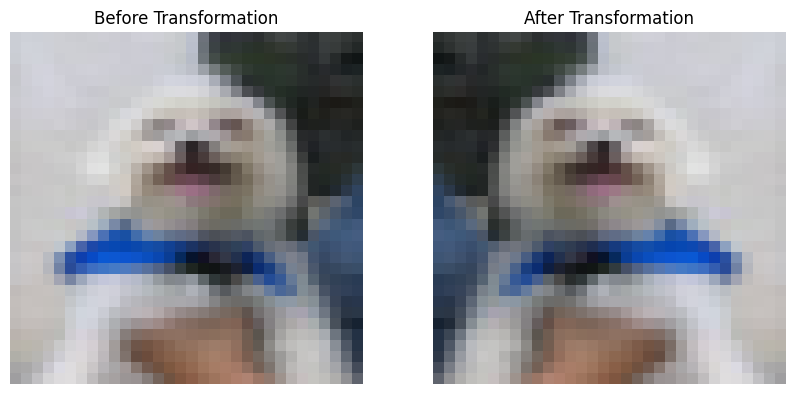

In [23]:
cifar_train = datasets.CIFAR10("./", train=True, download=True, transform=v2.ToTensor())
cifar_train_loader = torch.utils.data.DataLoader(cifar_train, batch_size=128, shuffle=True)

train_features, train_labels = next(iter(cifar_train_loader))
img = train_features[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,7))
transform = v2.Compose([v2.RandomHorizontalFlip()
                                # YOUR CODE HERE
                                ]) # Play with the transforms in https://docs.pytorch.org/vision/stable/transforms.html#v2-api-reference-recommended!
tensor_img = transform(img)
ax1.imshow(img.permute(1,2,0))
ax1.axis("off")
ax1.set_title("Before Transformation")
ax2.imshow(tensor_img.permute(1, 2, 0))
ax2.axis("off")
ax2.set_title("After Transformation")
plt.show()

### Task 2.3 - Picking Data Augmentations

Pick your favourite data augmentations! Then, you can apply them to the images from the dataset.

We've already started you off with the necessary one [`v2.ToTensor`](https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.v2.ToTensor.html#torchvision.transforms.v2.ToTensor) that converts the original JPEG-format image to the PyTorch [`torch.Tensor`](https://docs.pytorch.org/docs/stable/tensors.html) format. 

**Your task is to choose at least 2 additional augmentations from [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html) to apply to your images.** 
- Tell us which augmentations you chose to use and why. 
- Then tell us which augmentations you avoided and why. 

Be creative and try different things! We recommend using trial and error to get the best performing network. Are you surprised by which transformations happen to work the best?
__Note:__ Do ensure your augmentations retain the 3-dimensional shape of the CIFAR-10 images. The final images should still have the shape `(3, 32, 32)`.

In [271]:
# pick your data augmentations here
def get_augmentations() -> transforms.Compose:
    T = transforms.Compose([
        transforms.ToTensor(),
        transforms.RandomRotation(45),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
    ])
    return T

In [272]:
# Test cases
T = get_augmentations()

x = torch.rand(32, 32, 3).numpy()
x_t = T(x)
x_to_tensor_only = transforms.ToTensor()(x)

assert torch.is_tensor(x_t), "Output is not a tensor!"
assert not torch.all(x_t == x_to_tensor_only), "Transforms do not do anything other than converting input to tensor!"
assert x_t.shape == (3, 32, 32), f"Expected output shape of (3, 32, 32) but got {x_t.shape}"

### Demo 2.5 - Writing Custom Data Augmentations

Sometimes, you might want to write your own custom data augmentation that is not available in the `transforms` module. You can do this by creating a class that inherits from `torch.nn.Module` and implementing the `forward` method to perform the desired transformation on the input image tensor.

Below is an example of a data augmentation that shuffles the channels of the input image tensor. 

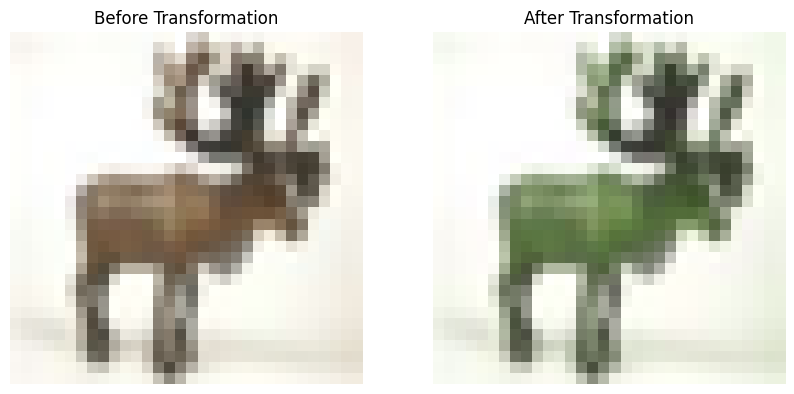

In [232]:
class ShuffleChannels(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, image):
        """
        Randomly permutes the channels of `image`.

        image: a tensor of shape (C, H, W) where C is the number of channels, 
               H is the height, and W is the width of the image.
        """
        permuted_indices = torch.randperm(image.shape[0])
        return image[permuted_indices]
    
# Example output of ShuffleChannels
train_features, train_labels = next(iter(cifar_train_loader))
img = train_features[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,7))
shuffle = ShuffleChannels()
tensor_img = shuffle(img)

ax1.imshow(img.permute(1,2,0))
ax1.axis("off")
ax1.set_title("Before Transformation")
ax2.imshow(tensor_img.permute(1, 2, 0))
ax2.axis("off")
ax2.set_title("After Transformation")
plt.show()

### Task 2.4 - Write a Custom Data Augmentation

Write your own custom data augmentation `SimulateRGBA` that adds an additional channel to the **unnormalized** RGB image tensor.
The input image tensor should have the shape `(3, H, W)` and the output image tensor should have the shape `(4, H, W)`.

**Note**
- The new channel should contain values between 0 and 1 to simulate the transparency channel in RGBA images,
- It should also be a non-trivial transformation of the original image tensor (i.e., not just random noise or a channel of constant value).

In [5]:
class SimulateRGBA(nn.Module):
    def __init__(self):
        super().__init__()
        # You may add any class attributes you need here

    def forward(self, image):
        """
        Adds a new channel to `image` that simulates an alpha channel.

        image: a tensor of shape (C, H, W) where C is the number of channels, 
               H is the height, and W is the width of the image, with values
               in the range [0, 1].
        """
        """ YOUR CODE HERE """
        _, H, W = image.shape
        alpha = torch.ones((1,H,W))
        return torch.cat((alpha, image))
        """ YOUR CODE END HERE """

In [6]:
# Test cases
rand_input = torch.rand(3, 28, 28)
simulate_rgba = SimulateRGBA()
output = simulate_rgba(rand_input)

assert output.shape == (4, 28, 28), f"Expected output shape of (4, 28, 28) but got {output.shape}"

alpha_channel = output[3]
assert torch.all((alpha_channel >= 0) & (alpha_channel <= 1)), "Values in the new channel should be in the range [0, 1]"
assert not torch.all(alpha_channel == alpha_channel[0, 0]), "Values in the new channel should not be all the same"

Now, we can compose our custom data augmentation together with the other augmentations we have chosen to create a powerful data transformation pipeline for our CIFAR-10 dataset!

**Note the order of the transformations in the `transforms.Compose` pipeline.** 
- The order of transformations matters because it will affect the logic of your pipeline
- This ultimately impacts the performance of your model (for better, or worse.)
    - If you apply `SimulateRGBA` before `ShuffleChannels`, the new channel added by `SimulateRGBA` will **also** be shuffled by `ShuffleChannels`
    - This means your intended alpha channel will act as a color channel instead, and your model will not learn the intended features from the alpha channel.

**Hint: If you are using your custom `SimulateRGBA` augmentation, followed by `transforms.Normalize(...)`, make sure to set the `mean` and `std` parameters in `transforms.Normalize(...)` to be 4-dimensional instead of 3-dimensional, to account for the additional channel added by `SimulateRGBA`.**

In [ ]:
# do not remove this cell
# run this before moving on

def get_augmentations() -> transforms.Compose:
    T = transforms.Compose([
        transforms.ToTensor(),
        # ShuffleChannels(), # Uncomment this line to test out the demo ShuffleChannels transformation
        # SimulateRGBA(), 
        # --- You are free to experiment with more custom transformations! ---
        # Add in your data augmentations from Task 2.3 here
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        transforms.RandomRotation(45),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip()
    ])
    
    return T

T = get_augmentations()

cifar_train = datasets.CIFAR10("./", train=True, download=True, transform=T)
cifar_test = datasets.CIFAR10("./", train=False, download=True, transform=T)

"""
if you feel your computer can't handle too much data, you can reduce the batch
size to 64 or 32 accordingly, but it will make training slower. 

We recommend sticking to 128 but do choose an appropriate batch size that your
computer can manage. The training phase tends to require quite a bit of memory.

CIFAR-10 images have dimensions 3x32x32, while MNIST is 1x28x28
"""
cifar_train_loader = torch.utils.data.DataLoader(cifar_train, batch_size=128, shuffle=True)
cifar_test_loader = torch.utils.data.DataLoader(cifar_test, batch_size=10000)

### Task 2.5 - Build a ConvNet for CIFAR-10

Your task is to build a decently-sized ConvNet (i.e., $\geq 4$ layers). Design your ConvNet with the following architecture

$$
\text{Conv(32, (3,3))} \rightarrow \text{MP((2,2))} \rightarrow \text{LReLU(0.1)} \rightarrow \text{Conv(64, (3,3))} \rightarrow \text{MP((2,2))} \rightarrow \text{LReLU(0.1)} \rightarrow \text{GAP} \\ \rightarrow \text{L(64, 256)} \rightarrow \text{LReLU(0.1)} \rightarrow \text{L(256, 128)} \rightarrow \text{LReLU(0.1)} \rightarrow \text{L(128, 10)} \rightarrow \text{Softmax}
$$

where 
- [`Conv`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) is a [`nn.Conv2d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) Convolutional layer with the specified output channels and kernel size

- [`MP`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) is a [`nn.MaxPool2d`](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) Max Pooling layer with the specified kernel size

- [`LReLU`](https://pytorch.org/docs/stable/generated/torch.nn.LeakyReLU.html) is a [`nn.LeakyReLU`](https://pytorch.org/docs/stable/generated/torch.nn.LeakyReLU.html) Leaky ReLU with the specified negative slope

- `GAP` is the Global Average Pooling operation (already implemented for you)

- [`L`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) is an [`nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) fully-connected layer with the specified input and output features

---

You must use the [`nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html) API to build two parts:
1. The `self.conv` attribute must contain all the Convolutional, Pooling, and Activation layers
2. The `self.fc` attribute must contain all the fully-connected layers after the flattening

The `self.conv` and `self.fc` attributes are already given to you. All you need to do is chain the arbitrary `nn.XYZ` layers together based on the architecture stated above.

__Note:__ 
- The flattening is already done for you via Global Average Pooling (GAP) in the `forward` method. 
- **YOU MUST** use the [`nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html) API to build the `self.conv` and `self.fc` attributes. 
- **DO NOT** add any layers outside of the [`nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html) blocks for `self.conv` and `self.fc`.
- **DO NOT** perform softmax in the `self.fc` Sequential module. Again, [`nn.CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) already applies softmax for us during the loss computation.

__Reminders:__ 
- Do not hardcode for the number of classes. Use the `classes` argument instead.
- Ensure that the first layer in `self.conv` takes in the correct number of input channels, depending on whether you are using your custom `SimulateRGBA` augmentation or not.

In [31]:
class CIFARCNN(nn.Module):
    def __init__(self, classes: int):
        super().__init__()
        """
        classes: integer that corresponds to the number of classes for CIFAR-10
        """
        self.conv = nn.Sequential(
                        nn.Conv2d(3, 32, (3,3)),
                        nn.MaxPool2d((2,2)),
                        nn.LeakyReLU(0.1),
                        nn.Conv2d(32, 64, (3,3)),
                        nn.MaxPool2d((2,2)),
                        nn.LeakyReLU(0.1),
                    )

        self.fc = nn.Sequential(
                        nn.Linear(64, 256),
                        nn.LeakyReLU(0.1),
                        nn.Linear(256, 128),
                        nn.LeakyReLU(0.1),
                        nn.Linear(128, classes),
                    )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """ YOUR CODE HERE """
        x = self.conv(x)
        """ YOUR CODE END HERE """
        x = x.view(x.shape[0], 64, 6*6).mean(2) # GAP – do not remove this line
        """ YOUR CODE HERE """
        out = self.fc(x)
        """ YOUR CODE END HERE """
        return out
    
    def predict_proba(self, x: torch.Tensor) -> torch.Tensor:
        out = self.forward(x)
        return torch.softmax(out, dim = 1)

### Train your ConvNet on CIFAR-10

In [32]:
%%time
# do not remove – nothing to code here
# run this cell before moving on

cifar10_model, cifar10_losses = train_model(CIFARCNN(10), cifar_train_loader, epochs = 3)

Epoch 1/3, Loss: 2.3237
Epoch 2/3, Loss: 2.3237
Epoch 3/3, Loss: 2.4237
CPU times: user 16min 44s, sys: 3.4 s, total: 16min 47s
Wall time: 3min 12s


### Test the CIFAR-10 ConvNet model using the testing data loader

In [35]:
# do not remove – nothing to code here
# run this cell before moving on
# but ensure get_accuracy from task 3.5 is defined

with torch.no_grad():
    cifar10_model.eval()
    for i, data in enumerate(cifar_test_loader):
        x, y = data
        x, y = x.to(device), y.to(device)
        pred = cifar10_model.predict_proba(x)
        acc = get_accuracy(pred, y)
        print(f"cifar accuracy: {acc}")
        
# don't worry if the CIFAR-10 accuracy is low, it's a tough dataset to crack.
# as long as you get something shy of 50%, you should be alright!

cifar accuracy: 0.14470000565052032


### Task 2.6 - Training on RGB vs. RGBA Images

Train your ConvNet on the CIFAR-10 dataset with **and** without your custom `SimulateRGBA` data augmentation. 

Compare the performance of the model trained on RGB images vs. RGBA images. Include any screenshots of model performance metrics, such as training and testing accuracy/loss curves, to support your analysis.

Some possible points you can explore:
- Does adding the additional channel with `SimulateRGBA` improve the performance of the model? Why or why not?
- Is there a difference in training time when using `SimulateRGBA`? Why or why not?

## 3 - Recurrent Neural Networks (RNNs)
In this part, we'll explore how an RNN works, and create a simple RNN model to predict values of a sine wave based on prior inputs.

### Packages
The necessary packages are imported in the cell below. Please make sure that you run this cell before proceeding.

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence

import numpy as np
import matplotlib.pyplot as plt

# Set seeds for reproducibility
torch.manual_seed(2109)
np.random.seed(2109)

In [37]:
# Check if GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu



### Concept: Memory

Traditional models like MLPs or CNNs can be **extremely coarsely** thought of as approximators of multivariate, vector-valued functions (if that meant nothing to you, don't worry about it). This idea looks like this in mathematical notation, with inputs $\mathbf{x} \in \mathbb{R}^n$ and outputs $\mathbf{y} \in \mathbb{R}^m$:
$$\text{MLP/CNN}: \mathbb{R}^n \mapsto \mathbb{R}^m, \text{MLP/CNN}(\mathbf{x}) = \mathbf{y}$$

This is good and all for simple tasks, but kind of falls short when we want to model **sequential data**.

There are a few things special about sequential data that break typical MLPs and CNNs:
- The data points in successive timesteps are correlated with each other (e.g. if I showed you a video of someone doing a slam dunk, you kind of know how the person will move in the next few frames, even if you haven't seen those frames yet.)
- These correlations can be extremely long range (e.g. I wouldn't **expect** a soccer team that has scored 10 goals in the first 10 minutes of the game to lose in the next 80 minutes)

We need to capture those characteristics in order to make a good model. Hence, we try a different formulation with an additional input $\mathbf{h}_{t-1} \in \mathbb{R}^h$ and output $\mathbf{h}_t \in \mathbb{R}^h$ to encapsulate the "memory" of the RNN:

$$\text{RNN}: \mathbb{R}^n \times \mathbb{R}^h \mapsto \mathbb{R}^m \times \mathbb{R}^h, \text{RNN}(\mathbf{x}_t, \mathbf{h}_{t-1}) = (\mathbf{y}_t, \mathbf{h}_t)$$

**In English, we not only transform the data that is fed in, but we also use that info to update our macroscopic perception at each step. That is the essence of memory.**

### Demo 3.1 - RNN Cell

<center><img src="images/rnn_unfolded.png" style="width:800px"></center>
<center>Source: Edited from <a href="https://wikidocs.net/166318" target="_blank">https://wikidocs.net/166318</a></center>

RNN models also distinguish themselves from MLPs and CNNs in that we typically ingest data sequentially rather than all at once. Hence, **we need multiple forward passes** (each with different data and memory content) to process the entire sequence.

(Above, Left) This is exactly what the RNN cell is doing given a sequence of inputs $\mathbf{x} = (x^{[0]}, x^{[1]}, ..., x^{[T]})$ and an initial hidden state $h^{[0]}$.

(Above, Right) Upon closer inspection, for each time step, the cell ingests the input $x^{[t]}$ and the previous hidden state $h^{[t-1]}$, and outputs a prediction $\hat{y}^{[t]}$ and an updated hidden state $h^{[t]}$. 

<center><img src="images/rnn_cell_superscript_updated.png" style="width:800px"></center>
(Above) If we zoom in even further, we also have a schematic of the internal workings of the RNN cell. 

__Note__: An RNN cell outputs the hidden state $h^{[t]}$, but the function that you'll implement `rnn_cell_forward`, also calculates the prediction $\hat{y}^{[t]}$. Keep in mind that the activation functions within the RNN cell can be replaced with other activation functions. This implementation uses tanh and softmax but they can be replaced by other activation functions as well.

In [38]:
def rnn_cell_forward(xt, h_prev, Wxh, Whh, Why, bh, by):
    """
    Implements a single forward step of the RNN-cell

    Args:
        xt: 2D tensor of shape (nx, m)
            Input data at timestep "t"
        h_prev: 2D tensor of shape (nh, m)
            Hidden state at timestep "t-1"
        Wxh: 2D tensor of shape (nx, nh)
            Weight matrix multiplying the input
        Whh: 2D tensor of shape (nh, nh)
            Weight matrix multiplying the hidden state
        Why: 2D tensor of shape (nh, ny)
            Weight matrix relating the hidden-state to the output
        bh: 1D tensor of shape (nh, 1)
            Bias relating to next hidden-state
        by: 2D tensor of shape (ny, 1)
            Bias relating the hidden-state to the output

    Returns:
        yt_pred -- prediction at timestep "t", tensor of shape (ny, m)
        h_next -- next hidden state, of shape (nh, m)
    """
    # The math is extremely confusing until you realise what is actually happening:
    # 1. The memory for this timestep is some combination of:
    #    a. The memory from the previous timestep (h_prev @ Whh)
    #    b. The new information from the current input (xt @ Wxh)
    #    c. A bias term (bh)
    h_next = torch.tanh(Whh.T @ h_prev + Wxh.T @ xt + bh)

    # Whereas the output is determined by:
    #   a. The memory from the current timestep (h_next @ Why)
    #   b. A bias term (by)
    #   c. A nonlinear activation function (here, softmax)
    yt_pred = F.softmax(Why.T @ h_next + by, dim=0)

    # In other words, the RNN does not DIRECTLY use the input xt to compute the output yt_pred.
    # Instead, it will update its memory to best represent the current data,
    # and then use this memory to perform the prediction.
    
    return yt_pred, h_next

### Demo 3.2 - Generate Sine Wave Data

We'll see the RNN in action by training it to predict the next value of a sine wave given the previous values.

Because a sine wave has predictable patterns, it is a good toy dataset to test out the capabilities of our RNN model.

We'll use [`torch.linspace`](https://pytorch.org/docs/stable/generated/torch.linspace.html) to create a sequence of evenly spaced values between 0 and $16\pi$ over `num_time_steps` intervals. This will serve as the x-values (time points) for the sine wave.

In [39]:

def generate_sine_wave(num_time_steps):
    """
    Generates a sine wave data

    Args:
        num_time_steps: int
            Number of time steps
    Returns:
        data: 1D tensor of shape (num_time_steps,)
            Sine wave data with corresponding time steps
    """
    x = torch.linspace(0, 16*torch.pi, num_time_steps)
    data = torch.sin(x)
    return data

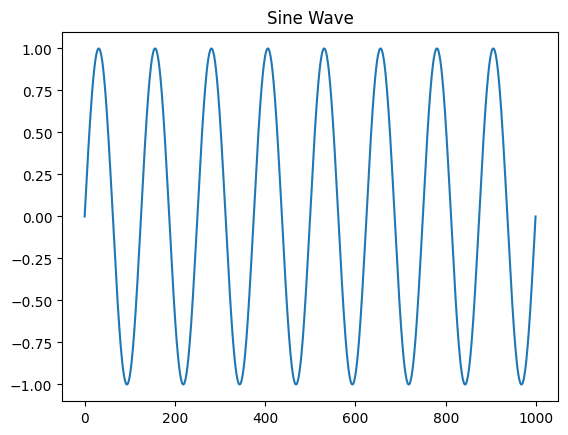

In [40]:
num_time_steps = 1_000
sine_wave_data = generate_sine_wave(num_time_steps)

# Plot the sine wave
plt.plot(sine_wave_data)
plt.title('Sine Wave')
plt.show()

### Demo 3.3 - Create sub-sequences from sine wave data

When training RNNs, it's common to divide time series data into overlapping windows. The label used for comparison is the next value in the sequence.

For example if we have series of $n$ data points and a window size of 3, the input sequences are 
$$[x^{[1]}, x^{[2]}, x^{[3]}] \mapsto x^{[4]}$$
$$[x^{[2]}, x^{[3]}, x^{[4]}] \mapsto x^{[5]}$$
$$[x^{[3]}, x^{[4]}, x^{[5]}] \mapsto x^{[6]}$$
and so on.

This redundancy helps the model to learn better because it receives multiple auxiliary signals (i.e. did I predict the next point correctly?) to help it learn the underlying pattern of the sine wave better.

Below is our implementation of `create_sequences` which generates sequences and their corresponding labels from a given sine wave.

In [41]:
def create_sequences(sine_wave, seq_length):
    """
    Create overlapping sequences from the input time series and generate labels 
    Each label is the value immediately following the corresponding sequence.
    
    Args:
        sine_wave: A 1D tensor representing the time series data (e.g., sine wave).
        seq_length: int. The length of each sequence (window) to be used as input to the RNN.

    Returns: 
        windows: 2D tensor where each row is a sequence (window) of length `seq_length`.
        labels: 1D tensor where each element is the next value following each window.
    """
    windows = sine_wave.unfold(0, seq_length, 1)
    labels = sine_wave[seq_length:]
    return windows[:-1], labels

In [42]:
# Create sequences and labels
seq_length = 20
sequences, labels = create_sequences(sine_wave_data, seq_length)
# Add extra dimension to match RNN input shape [batch_size, seq_length, num_features]
sequences = sequences.unsqueeze(-1)
sequences.shape

torch.Size([980, 20, 1])

In [50]:
# Split the sequences into training data (first 50%) and test data (remaining 50%) 
train_size = int(len(sequences) * 0.5)
train_seqs, train_labels = sequences[:train_size], labels[:train_size]
test_seqs, test_labels = sequences[train_size:], labels[train_size:]

### Task 3.1 - Building RNN Model

Now we're ready to build our RNN model, following the architecture:
$$x \rightarrow \text{RNN} \rightarrow \text{Linear}(1)$$

- [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html): the [`nn.RNN`](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html) layer in PyTorch, which behaves like the first image you saw in Demo 3.1, processing the data sequentially and maintaining a hidden state across time steps.

**NOTE**: This is **NOT** the same as [`nn.RNNCell`](https://pytorch.org/docs/stable/generated/torch.nn.RNNCell.html), which only performs **ONE** step of the RNN. Recall we mentioned above that RNNs require **multiple forward passes** to do their magic. 
 
- [Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html): an [`nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) linear layer. The output from the RNN's last hidden state will be passed through this layer to predict a single value (the next time step in the series)

We'll do so by defining the `__init__` and `forward` functions in our `SineRNN` class, which inherits from [`nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html).

__Note:__ 
- For all your networks hereon, the only constructor argument is `classes`. 
- Do not add any other parameters to the `__init__` method. 
- Remember not to hardcode and use the `classes` argument instead. 
- For RNN layer, use `batch_first=True` to ensure that the batch dimension is handled as the first input dimension.

In [139]:
class SineRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        """
        Initialize the SineRNN model.

        Args:
            input_size (int): The number of input features per time step (typically 1 for univariate time series).
            hidden_size (int): The number of units in the RNN's hidden layer.
            output_size (int): The size of the output (usually 1 for predicting a single value).
        """
        super(SineRNN, self).__init__()
        """ YOUR CODE HERE """
        self.rnn = nn.RNN(input_size, hidden_size, batch_first= True)
        self.l1 = nn.Linear(hidden_size, output_size)
        """ YOUR CODE END HERE """
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """ YOUR CODE HERE """
        output, gg = self.rnn(x)
        x = self.l1(output[:,-1])
        return x
        """ YOUR CODE END HERE """

In [140]:
# Test cases
input_size = output_size = 1
hidden_size = 50
model = SineRNN(input_size, hidden_size, output_size).to(device)
assert [layer.detach().numpy().shape for _, layer in model.named_parameters()]\
      == [(50, 1), (50, 50), (50,), (50,), (1, 50), (1,)]

### Training

In [141]:
# Define loss function, and optimizer
criterion = nn.MSELoss() # Quick quiz: Why are we using MSELoss?
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)

In [142]:
# Training loop
num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(train_seqs)
    loss = criterion(outputs.squeeze(), train_labels)

    # Backward pass and optimization
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

Epoch [20/200], Loss: 0.011468
Epoch [40/200], Loss: 0.001701
Epoch [60/200], Loss: 0.000171
Epoch [80/200], Loss: 0.000054
Epoch [100/200], Loss: 0.000043
Epoch [120/200], Loss: 0.000037
Epoch [140/200], Loss: 0.000034
Epoch [160/200], Loss: 0.000031
Epoch [180/200], Loss: 0.000028
Epoch [200/200], Loss: 0.000026


### Evaluating

Once training is complete, we can evaluate the model by plotting its predictions against the actual sine wave. We use a portion of test data that the model hasn't seen during training to check how well it generalizes.

In [143]:
# Predict on unseen data
model.eval()
y_pred = []
input_seq = test_seqs[0]  # Start with the first testing sequence

with torch.no_grad():
    for _ in range(len(test_seqs)):
        output = model(input_seq)
        y_pred.append(output.item())

        # Use the predicted value as the next input sequence
        next_seq = torch.cat((input_seq[1:, :], output.unsqueeze(0)), dim=0)
        input_seq = next_seq

# Plot the true sine wave and predictions
plt.plot(sine_wave_data, c='gray', label='Actual data')
plt.scatter(np.arange(seq_length + len(train_labels)), sine_wave_data[:seq_length + len(train_labels)], marker='.', label='Train')
x_axis_pred = np.arange(len(sine_wave_data) - len(test_labels), len(sine_wave_data))
plt.scatter(x_axis_pred, y_pred, marker='.', label='Predicted')
plt.legend(loc="lower left")
plt.show()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x20 and 50x1)

### Demo 3.4 - Appending Noise to Sequences

In real-world data, sequences often contain noise or fluctuations that can make predictions more challenging. To simulate this, we can append random noise to our sine wave sequences.

In this demo, we will append a sequence of noises to the sine wave sequences. The model has to learn to predict the sine wave despite the added noise.

In [144]:
def create_sequences_with_noise(sine_wave, sine_wave_length, noise_length):
    """
    Create overlapping sequences from the input time series and generate labels.
    Each label is the value immediately following the corresponding sequence.
    Additionally, noise of the specified length is appended to the sequences.

    Args:
        sine_wave: A 1D tensor representing the time series data (e.g., sine wave).
        sine_wave_length: int. The length of the sine wave window.
        noise_length: int. The length of noise to be appended to each sequence.

    Returns:
        windows: 2D tensor where each row is a sequence of length `sine_wave_length + noise_length`.
        labels: 1D tensor where each element is the next value following each window.
    """
    windows = sine_wave.unfold(0, sine_wave_length, 1)
    labels = sine_wave[sine_wave_length:]
    noise = torch.randn(windows.shape[0], noise_length)
    windows = torch.cat((windows, noise), dim=1)
    return windows[:-1], labels

In [145]:
# Create sequences and labels
sine_wave_length = 20
noise_length = 20
sequences_noisy, labels_noisy = create_sequences_with_noise(sine_wave_data, sine_wave_length, noise_length)
# Add extra dimension to match RNN input shape [batch_size, seq_length, num_features]
sequences_noisy = sequences_noisy.unsqueeze(-1)
sequences_noisy.shape

torch.Size([980, 40, 1])

In [146]:
# Split the sequences into training data (first 50%) and test data (remaining 50%) 
train_size = int(len(sequences_noisy) * 0.5)
train_seqs_noisy, train_labels = sequences_noisy[:train_size], labels_noisy[:train_size]
test_seqs_noisy, test_labels = sequences_noisy[train_size:], labels_noisy[train_size:]

### Training

In [147]:
# Define model
input_size = output_size = 1
hidden_size = 50
model = SineRNN(input_size, hidden_size, output_size).to(device)

# Define loss function, and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)

In [148]:
# Training loop
num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    outputs = model(train_seqs_noisy)
    loss = criterion(outputs.squeeze(), train_labels)

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

Epoch [20/200], Loss: 0.405005
Epoch [40/200], Loss: 0.354378
Epoch [60/200], Loss: 0.330728
Epoch [80/200], Loss: 0.245362
Epoch [100/200], Loss: 0.241845
Epoch [120/200], Loss: 0.226271
Epoch [140/200], Loss: 0.148455
Epoch [160/200], Loss: 0.123922
Epoch [180/200], Loss: 0.137104
Epoch [200/200], Loss: 0.121064


### Evaluating

Test loss: tensor(0.1025)


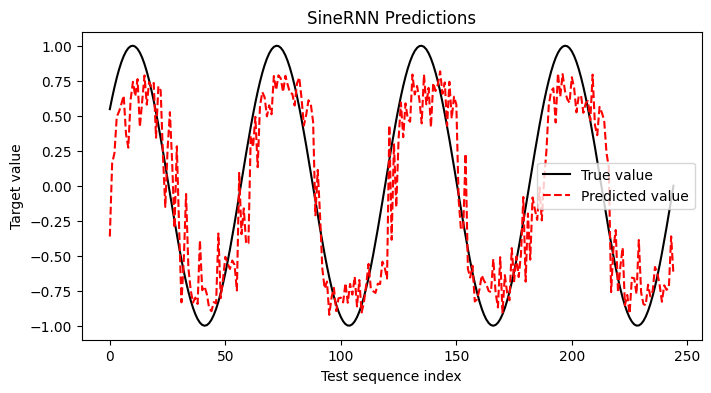

In [149]:
model.eval()
with torch.no_grad():
    y_pred = model(test_seqs_noisy).squeeze()
    y_true = test_labels.squeeze()

print("Test loss:", criterion(y_pred, y_true))

plt.figure(figsize=(8, 4))
plt.plot(y_true[1::2].numpy(), label="True value", color='black')
plt.plot(y_pred[1::2].numpy(), '--', label="Predicted value", color='red')
plt.title("SineRNN Predictions")
plt.xlabel("Test sequence index")
plt.ylabel("Target value")
plt.legend()
plt.show()

As we increase the length of the noise appended to the sequence, it gets harder and harder for the RNN to predict the sine wave accurately.

Note that RNNs processes the data sequentially, so RNNs often face difficulties retaining information over long sequences.

# 4 - Attention Mechanism and Transformers

RNNs are inherently handicapped by the fact that they must process data sequentially with a finite memory capacity. 
This makes it difficult for them to capture long-range dependencies in the data, and also makes them computationally inefficient for long sequences.

Thus we use [**Attention Mechanisms**](https://arxiv.org/abs/2204.13154), modern versions of which allow the model (such as the [Bahdanau attention mechanism (Bahdanau, Cho & Bengio, 2014)](https://d2l.ai/chapter_attention-mechanisms-and-transformers/bahdanau-attention.html)) access and attend to all hidden states across all time steps, rather than just the last hidden state. This allows the model to capture long-range dependencies and make more informed predictions.

In this exercise, we want to show you one of the most revolutionary architectures to implement **Attention Mechanisms**: the [**Transformer** (Vaswani et al., 2017)](https://arxiv.org/abs/1706.03762).

![](images/transformer.png)

The [**Transformer**](https://arxiv.org/abs/1706.03762) distinguishes itself from RNNs through completely eschewing the **recurrent component** of [Bahdanau attention](https://d2l.ai/chapter_attention-mechanisms-and-transformers/bahdanau-attention.html) and instead relying solely on the [dot-product attention mechanism](https://en.wikipedia.org/wiki/Attention_(machine_learning)#Dot-product_attention) to capture the relationships between different positions in the input sequence.

It lends itself **ludicrously well** to parallel computing, which allows it to be trained on much larger datasets and with much larger models than RNNs. Coupled with the hype of OpenAI's early successes with the Transformer architecture (creating [Generative Pre-trained Transformer (GPT)](https://openai.com/research/language-unsupervised)), the [Transformer](https://arxiv.org/abs/1706.03762) has become the go-to architecture for large language models (LLMs) and many other applications in natural language processing and beyond.

This is the key reason why it has become the de-facto architecture for most generative AI models today.

### Task 4.1 - Positional Encoding Layer

Positional encoding explicitly injects positional information into the inputs. We use the positional encoding scheme discussed in lecture, reproduced as follows:

$$
PE{(i, 2k)} = \sin\left(\dfrac{i}{10000^{2k/d}}\right) \\
PE{(i, 2k+1)} = \cos\left(\dfrac{i}{10000^{2k/d}}\right)
$$

where $d$ is the model's hidden dimension.

Implement the `PositionalEncoding` class, which extends from `nn.Module`, that generates positional encodings for input sequences.
- *In your implementation, you may assume that `hidden_size` is even.*
- *Take care to avoid Numpy operations in intermediate layers like this one, since they exist outside of torch's automatic differentiation system and will mess with backpropagation calculations.*

**Note for the curious**: Transformer layers are not a free-lunch improvement over RNN layers. You will see more of this in Task 4.3.

In [326]:
class PositionalEncoding(nn.Module):
    def __init__(self):
        # You do not need to change anything in this function.
        super(PositionalEncoding, self).__init__()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Adds positional encoding to the input tensor.

        You should use vectorized operations to compute the positional encoding.
        The use of Python loops is not allowed.

        Args:
            x: Input tensor of shape (batch_size, seq_len, hidden_size)
        """
        """ YOUR CODE HERE """
        batch_size, seq_len, hidden = x.shape
        positions = torch.arange(0, seq_len, 1).unsqueeze(1)
        numbers = torch.arange(0, hidden, 2)
        denominator = torch.pow(10000, numbers / hidden)
        pe = torch.zeros(seq_len, hidden)
        pe[..., 0::2] = torch.sin(positions / denominator)
        pe[..., 1::2] = torch.cos(positions / denominator)
        return x + pe
        """ YOUR CODE END HERE """

In [327]:
# Test cases
encoder = PositionalEncoding()
x0 = torch.zeros((1, 2, 4))
y0 = encoder(x0)
a0 = torch.tensor([[[0.0000, 1.0000, 0.0000, 1.0000],
                    [0.8415, 0.5403, 0.0100, 0.9999]]])

assert isinstance(y0, torch.Tensor), "Output is not a tensor!"
assert torch.allclose(y0, a0, atol=1e-4)

x1 = torch.ones((1, 4, 6))
y1 = encoder(x1)
a1 = torch.tensor([[[1.0000, 2.0000, 1.0000, 2.0000, 1.0000, 2.0000],
                    [1.8415, 1.5403, 1.0464, 1.9989, 1.0022, 2.0000],
                    [1.9093, 0.5839, 1.0927, 1.9957, 1.0043, 2.0000],
                    [1.1411, 0.0100, 1.1388, 1.9903, 1.0065, 2.0000]]])

assert torch.allclose(y1, a1, atol=1e-4)
assert isinstance(y1, torch.Tensor), "Output is not a tensor!"

### Demo 4.1 - The Transformer Model

Here, we will implement the model architecture for the transformer model using PyTorch. The transformer model consists of a single encoder layer with a specified hidden dimension in the feed-forward network.

A layer in the transformer model is defined using `nn.TransformerEncoderLayer`, with the following minimal usage:

```python
encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=2048, batch_first=False)
```
- `d_model` is the hidden dimension of the model.
- `nhead` is the number of attention heads. Each attention head is an independent self-attention mechanism that could possibly learn different aspects of the input sequence. In this transformer model, we will set `nhead=1` to implement only one self-attention mechanism.
- `dim_feedforward` is the hidden dimension of the feed-forward network.
- `batch_first=True` ensures that the input and output tensors are of shape `(batch_size, seq_length, hidden_dim)`, which is convenient for our implementation.


The transformer encoder is then defined using `nn.TransformerEncoder`, which takes the encoder layer and the number of layers as arguments:

```python
transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
```
- `num_layers=1` specifies that we will use only one encoder layer.

There are other optional parameters that can be set, you may refer to the [PyTorch documentation](https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html) for more details.

In [328]:
class TransformerNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        """
        Initializes the TransformerNN model. We use the same hidden size for the feedforward network and the Transformer encoder.

        Args:
            input_size (int): The number of input features per time step (typically 1 for univariate time series).
            hidden_size (int): The number of units in the Transformer's hidden layers.
            output_size (int): The size of the output (usually 1 for predicting a single value).
        """
        super(TransformerNN, self).__init__()
        self.embedding = nn.Linear(input_size, hidden_size)
        self.positional_encoder = PositionalEncoding()
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_size, dim_feedforward=hidden_size, nhead=1, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.fc_out = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.embedding(x)
        x = self.positional_encoder(x)
        x = self.transformer_encoder(x)

        # The encoder outputs a sequence of hidden states, so
        # we take the mean across the sequence length dimension.
        x = x.mean(dim=1)

        out = self.fc_out(x)
        return out

### Training

In [329]:
model = TransformerNN(input_size=1, hidden_size=50, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [330]:
num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(train_seqs_noisy)
    loss = criterion(outputs.squeeze(), train_labels)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

Epoch [20/200], Loss: 0.144459
Epoch [40/200], Loss: 0.085781
Epoch [60/200], Loss: 0.014021
Epoch [80/200], Loss: 0.004769
Epoch [100/200], Loss: 0.003341
Epoch [120/200], Loss: 0.002767
Epoch [140/200], Loss: 0.002601
Epoch [160/200], Loss: 0.002296
Epoch [180/200], Loss: 0.002022
Epoch [200/200], Loss: 0.001749


### Evaluating

Test loss: tensor(0.0196)


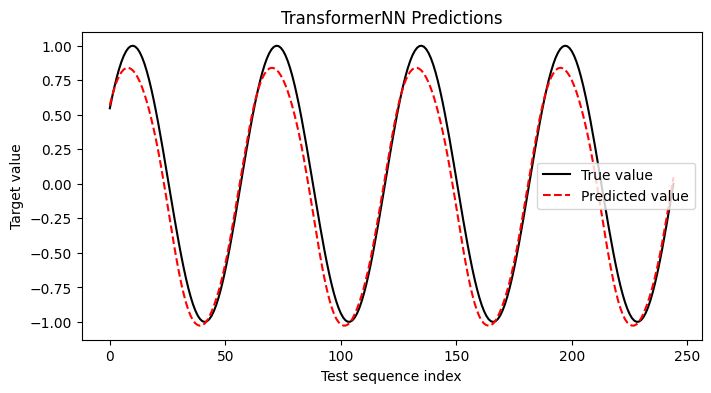

In [331]:
model.eval()
with torch.no_grad():
    y_pred = model(test_seqs).squeeze()
    y_true = test_labels.squeeze()

print("Test loss:", criterion(y_pred, y_true))

plt.figure(figsize=(8, 4))
plt.plot(y_true[1::2].numpy(), label="True value", color='black')
plt.plot(y_pred[1::2].numpy(), '--', label="Predicted value", color='red')
plt.title("TransformerNN Predictions")
plt.xlabel("Test sequence index")
plt.ylabel("Target value")
plt.legend()
plt.show()

### Task 4.2 - Visualizing Attention Scores

We can visualize the attention scores from the transformer model to understand which parts of the input sequence the model focuses on when making predictions.

Here are 3 different plots of attention scores, one of which is actually taken from the self-attention layer of our trained transformer model. Which of the 3 plots **most likely** corresponds to the attention scores from our trained transformer model? Explain your reasoning.

**Plot A**

![](images/attention_A.png)

**Plot B**

![](images/attention_B.png)

**Plot C**

![](images/attention_C.png)

**NOTE**: It does **NOT** suffice to print the attention map from your model and identify a plot based on that, and you will **NOT** get full credit for doing so.

### Task 4.3 - Discovering the Ingredients to Transformers' Success

Like we mentioned in Task 4.1, [Transformers](https://arxiv.org/abs/1706.03762) (on their own) are **not** a free-lunch improvement over RNNs.

For example:
1. Our transformer model currently makes use of the positional encoding layer, which was not required in an RNN.
2. Our transformer model currently is also allowed to attend to **ALL** positions in the input sequence, whereas an RNN can only attend to the previous hidden state.

Your task:
1. Train another transformer model **without the positional encoding layer** on the same dataset and evaluate its performance.

Attach the plots of both models on Coursemology. 
Discuss the differences in performance between the two models.

Based on your previous discussion, explain why positional encoding is important for transformer models when dealing with sequential data.

In [337]:
# You may use this cell and create new cells to experiment.
class TransformerNNWoEncoding(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        """
        Initializes the TransformerNN model. We use the same hidden size for the feedforward network and the Transformer encoder.

        Args:
            input_size (int): The number of input features per time step (typically 1 for univariate time series).
            hidden_size (int): The number of units in the Transformer's hidden layers.
            output_size (int): The size of the output (usually 1 for predicting a single value).
        """
        super(TransformerNNWoEncoding, self).__init__()
        self.embedding = nn.Linear(input_size, hidden_size)
        self.positional_encoder = PositionalEncoding()
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_size, dim_feedforward=hidden_size, nhead=1, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.fc_out = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer_encoder(x)

        # The encoder outputs a sequence of hidden states, so
        # we take the mean across the sequence length dimension.
        x = x.mean(dim=1)

        out = self.fc_out(x)
        return out

In [338]:
model = TransformerNNWoEncoding(input_size=1, hidden_size=50, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

/home/sad/Documents/GitHub/nus/CS2109_Introduction_to_AI_and_Machine_Learning/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


In [339]:
num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(train_seqs_noisy)
    loss = criterion(outputs.squeeze(), train_labels)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

Epoch [20/200], Loss: 0.171700
Epoch [40/200], Loss: 0.155501
Epoch [60/200], Loss: 0.150675
Epoch [80/200], Loss: 0.145643
Epoch [100/200], Loss: 0.139670
Epoch [120/200], Loss: 0.133388
Epoch [140/200], Loss: 0.129671
Epoch [160/200], Loss: 0.128310
Epoch [180/200], Loss: 0.127157
Epoch [200/200], Loss: 0.129224


Test loss: tensor(0.1455)


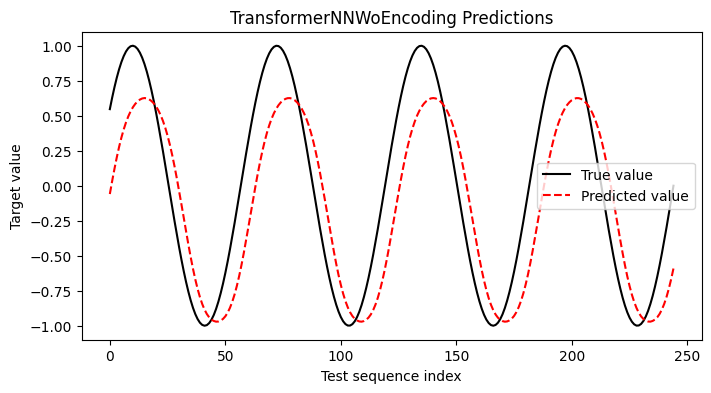

In [341]:
model.eval()
with torch.no_grad():
    y_pred = model(test_seqs).squeeze()
    y_true = test_labels.squeeze()

print("Test loss:", criterion(y_pred, y_true))

plt.figure(figsize=(8, 4))
plt.plot(y_true[1::2].numpy(), label="True value", color='black')
plt.plot(y_pred[1::2].numpy(), '--', label="Predicted value", color='red')
plt.title("TransformerNNWoEncoding Predictions")
plt.xlabel("Test sequence index")
plt.ylabel("Target value")
plt.legend()
plt.show()

## Submission

Once you are done, please submit your work to Coursemology, by copying the right snippets of code into the corresponding box that says "Your answer,"and click "Save." After you save, you can still make changes to your submission.

Once you are satisfied with what you have uploaded, click "Finalize submission." Note that once your submission is finalized, it is considered to be submitted for grading and cannot be changed. If you need to undo this action, you will have to email your assigned tutor for help. Please do not finalize your submission until you are sure that you want to submit your solutions for grading.

*Have fun and enjoy coding.*